# Personal Information
Name: **Merlijne Reeuwijk**

StudentID: **13706039**

Email: [**merlijne.reeuwijk@student.uva.nl**](merlijne.reeuwijk@student.uva.nl)

Submitted on: **23.03.2026**

GitHub: [**https://github.com/reepchocolade99/Thesis**](https://github.com/reepchocolade99/Thesis)

## Data Context

The legal firm of the municipality of Amsterdam, handles a lot of Objection cases. For most of these cases the verdict is the same, but for each case a seperate letter needs to be written. Each of these letters take a lot of time by the legal particioner, eventhough the letters don't differ much. To help the legal particioner with efficienting their workflow, a tool will be made that can write these letters for the legal particioner based on their input.

To create such a tool historical cases will be used. In the dataset are 330 historical *Huisvestigingswet* Housing Act Objection cases. This dataset is only a small anomynised data set to give an idea of how the data looks. For the actual training more data will be used. Inside the dataset all important details of this handled cases are given. Think of the Dictum, start-date, end-date, the date the final decision is sent and the letter that is used. This dataset belongs to the muncipality of Amsterdam. The data is in Dutch. Since the tool needs to be an Dutch language model, the training data are old Dutch cases.


# Data Description

The dataset utilized for this research consists of 329 anonymized historical objection cases provided by the municipality of Amsterdam. All documents are written in Dutch and pertain specifically to the Housing Act (Huisvestigingswet), with a focus on Holiday Rentals (Vakantieverhuur). The dataset contains 18 initial features, including critical metadata such as case numbers, primary decision dates, and the anonymized legal text (Legal_Text).

## 1. Introduction Data 
The goal is to create a tool that assists legal practitioners in writing objection letters. The lawyer determines the legal outcome (Dictum), and the RAG model generates the corresponding draft. Understanding the historical distribution of these decisions is crucial, as it shows which types of letters (e.g., *Ongegrond*) the model will be asked to generate most frequently.

These cases are all Hous Act cases. The data for the second comparison group, Housing Allocation (WRV), is currently still in the collection phase. As soon as this data is available, the EDA will be expanded to analyze the variation in model performance between these two domains, as formulated in sub-question Q2. 


In [28]:
# Imports
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
import re


In [ ]:
df = pd.read_csv(
    r'Data\vakantieverhuur.csv', 
    sep=';', 
    encoding='cp1252'
)


def map_subtype(subject):
    if 'verhuurvergunning' in str(subject).lower(): return 'Rental Permit'
    if 'bed&breakfast' in str(subject).lower(): return 'B&B'
    if 'verbodsgebieden' in str(subject).lower(): return 'Prohibited Areas'
    return 'Other'
df['Subtype'] = df['Onderwerp'].apply(map_subtype)


df['Legal_Text'] = df['geanonimiseerd_doc_inhoud']
print(f"Total cases in dataset: {len(df)}")

print("Number of cases per Subtype (Workload Overview):")
print(df['Subtype'].value_counts())

Total cases in dataset: 329
Number of cases per Subtype (Workload Overview):
Subtype
Rental Permit       192
B&B                 135
Prohibited Areas      2
Name: count, dtype: int64


To better understand the situation its important to look at the distribution of the decisions(dictum)  of each of these cases. Most of these cases are *ongegrond* (groundless) 66.8% of the time and *niet-onvakelijk* (inadmissible) 19.7% of the times. The first graph shows the distribution of dictums over the entire dataset, the second graphs show it per case type.

C:\Users\reeuwi006\AppData\Local\Temp\ipykernel_21656\819133427.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Dictum', palette='viridis', order=dictum_order)


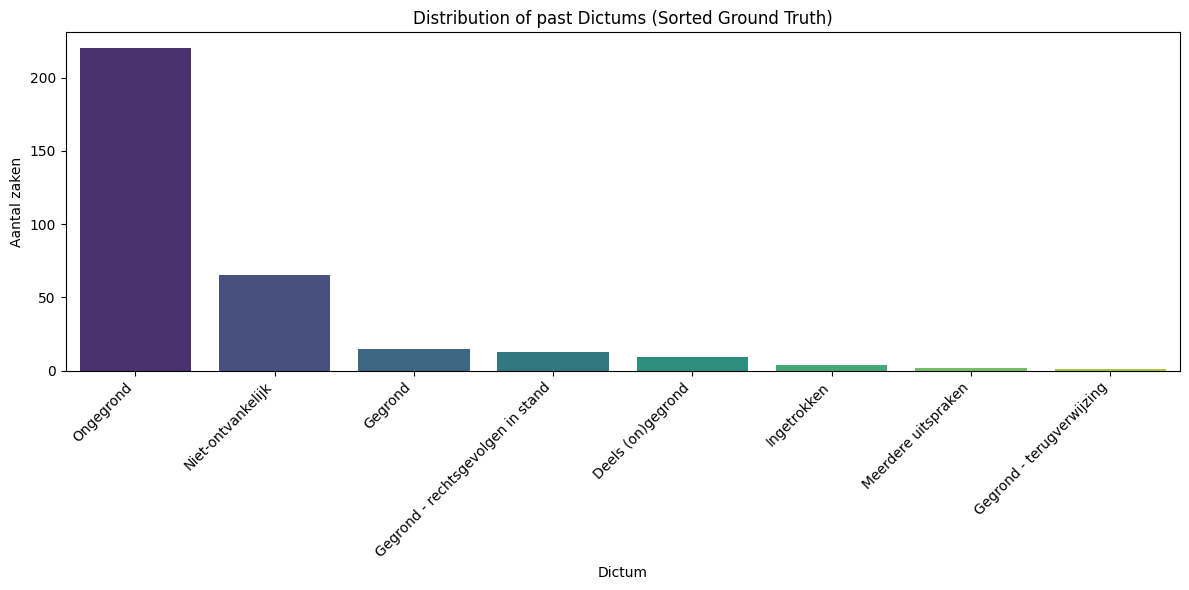

Percentage per Dictum:
 Dictum
Ongegrond                            66.869301
Niet-ontvankelijk                    19.756839
Gegrond                               4.559271
Gegrond - rechtsgevolgen in stand     3.951368
Deels (on)gegrond                     2.735562
Ingetrokken                           1.215805
Meerdere uitspraken                   0.607903
Gegrond - terugverwijzing             0.303951
Name: proportion, dtype: float64


In [26]:
# Overview
dictum_counts = df['Dictum'].value_counts(normalize=True) 

dictum_order = df['Dictum'].value_counts().index

plt.figure(figsize=(12, 6))

sns.countplot(data=df, x='Dictum', palette='viridis', order=dictum_order)
plt.title('Distribution of past Dictums (Sorted Ground Truth)')
plt.ylabel('Aantal zaken')
plt.xlabel('Dictum')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

dictum_counts = df['Dictum'].value_counts(normalize=True) * 100
print("Percentage per Dictum:\n", dictum_counts)

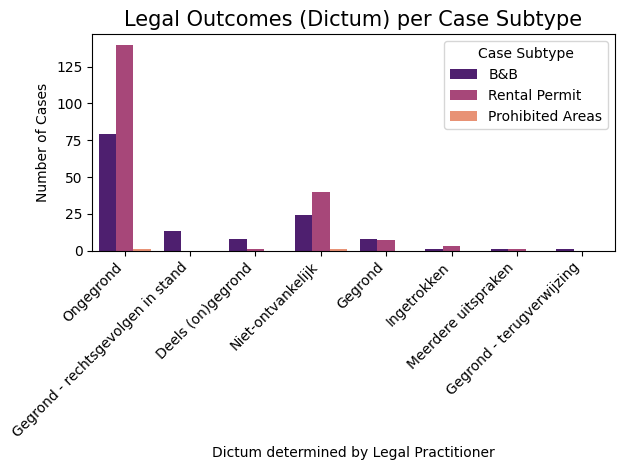

In [32]:
sns.countplot(data=df_hr, x='Dictum', hue='Subtype', palette='magma')

plt.title('Legal Outcomes (Dictum) per Case Subtype', fontsize=15)
plt.xlabel('Dictum determined by Legal Practitioner')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Case Subtype')

plt.tight_layout()
plt.show()

## 2. Data Cleaning
To generate a professional legal letter, the model must rely on high-quality source text.

In [25]:
missing_counts = df.isnull().sum() 
print("Missing Values per Column:\n", missing_counts)

Missing Values per Column:
 Octopus zaaknummer                0
Zaaktype                          0
Onderwerp                         0
Primair Besluit                   0
Verzenddatum primair besluit      0
Dictum                            0
Zaakstatus                        0
Startdatum                        0
Datum zitting                   216
Verzendatum besluit               2
Planningsdatum                    0
Afronddatum                       0
Omschrijving                    263
Richting                          0
Document afgebroken               0
geanonimiseerd_doc_inhoud         0
Subtype                           0
Legal_Text                        0
dtype: int64


### 2.1 Feature Planning
The dataset is generally clean; however, date fields and numerical identifiers were validated during import. The column *Omschrijving* (Description) was identified as unreliable. The entries were inconsistent, often missing, and lacked the standardized legal terminology found in the primary documents. Since a lawyer needs a precise draft, using noisy descriptions could lead to errors. By removing this column, the RAG model is forced to use the full 'Legal_Text', ensuring the draft letter is based on the actual legal grounds provided in the original cas

In [5]:
df['Omschrijving'].unique()

<StringArray>
[                                                                                                   nan,
 'Beslissing op bezwaar 5638/5669/5673/5945/6050/7051/8707/8710/9238/9518/10355/10802/11625/11625/1163',
                                                                                               'Advies',
                                                                                         'bob per mail',
                                                   'Beslissing op bezwaar, ons kenmerk JB.20.007067001',
                                                                           'aangepaste advies Jacobien',
                                                                                        'Verzonden bob',
                                                  'Beslissing op bezwaar, ons kenmerk JB.20.007682.001',
                                                  'Beslissing op bezwaar, ons kenmerk JB.20.008466.001',
                                         

In [ ]:
df.drop(columns=['Omschrijving'], inplace=True)

## 3. RAG Optimization 

For a RAG architecture, text granularity is essential for a successful chunking strategy. By analyzing word counts and sentence lengths, we can determine the optimal chunk_size and overlap to ensure the system does not cut off vital legal reasoning mid-sentence.

### 3.1 Word Distribution

Text(0.5, 0, 'Amount of Words per Case')

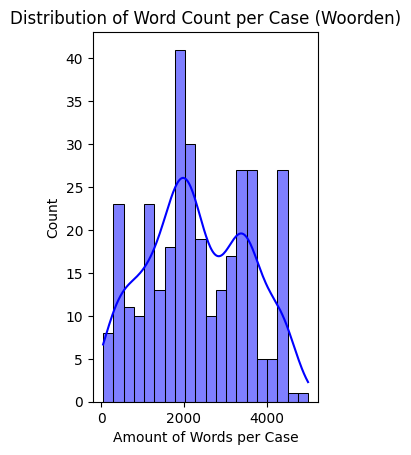

In [ ]:
df['Letter_Length'] = df['Legal_Text'].str.len()
df['Word_Count'] = df['Legal_Text'].str.split().str.len()


plt.subplot(1, 2, 2)
sns.histplot(df['Word_Count'], bins=20, kde=True, color='blue')
plt.title('Distribution of Word Count per Case (Woorden)')
plt.xlabel('Amount of Words per Case')


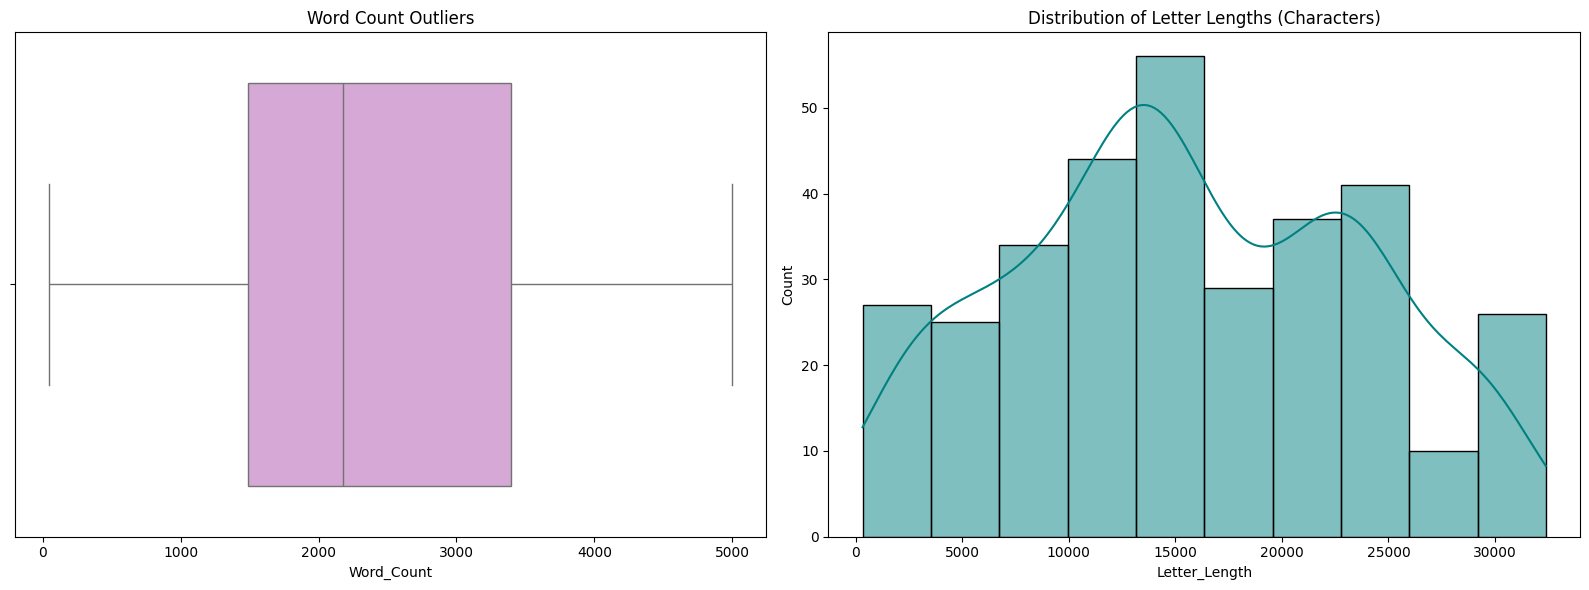

In [ ]:
# Word Count and -Length Distribution over the entire dataset

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.boxplot(ax=axes[0], data=df, x='Word_Count', color='plum')
axes[0].set_title('Word Count Outliers')


sns.histplot(ax=axes[1], data=df, x='Letter_Length', kde=True, color='teal')
axes[1].set_title('Distribution of Word Lengths (Characters)')


plt.tight_layout()
plt.show()

C:\Users\reeuwi006\AppData\Local\Temp\ipykernel_21656\3228104963.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x='Subtype', y='word_count', palette='viridis')


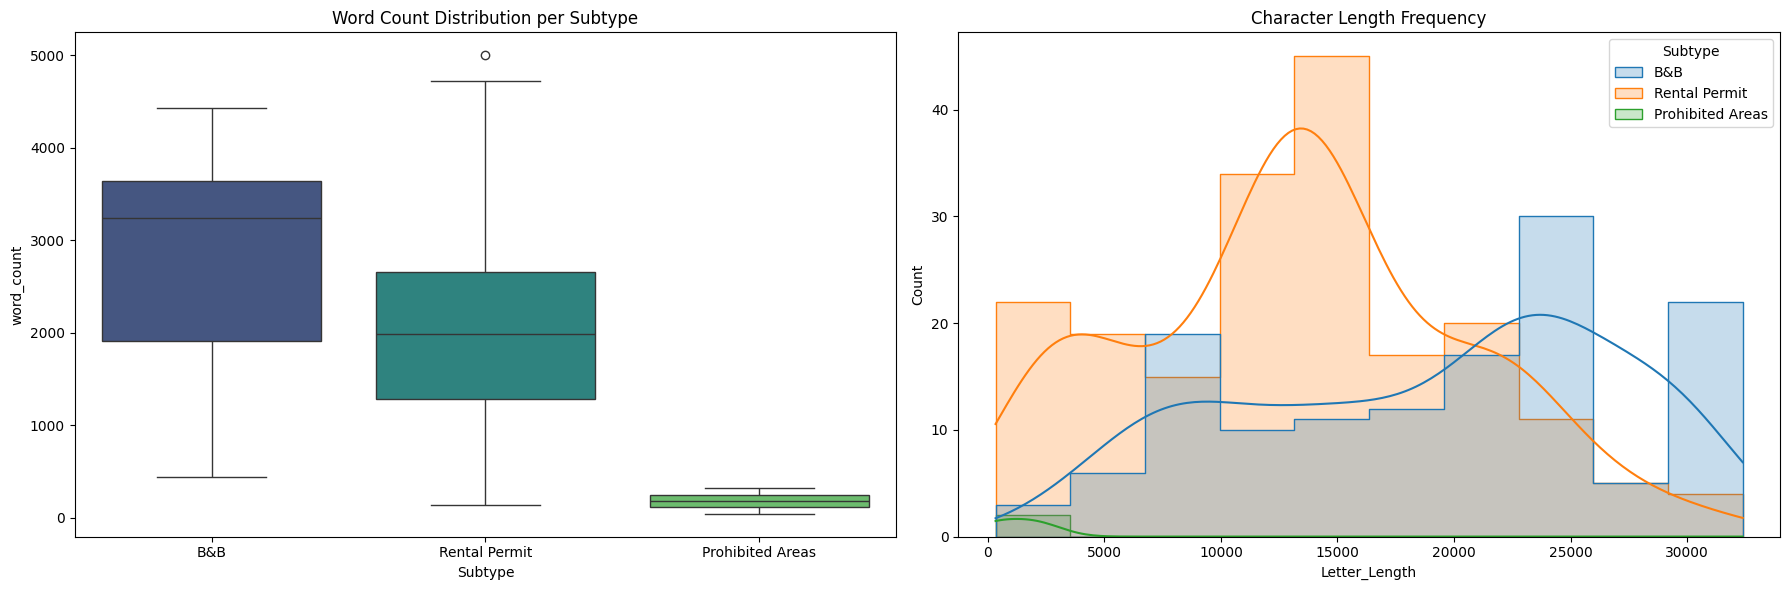

                  count    mean     std    min     25%     50%     75%     max
Subtype                                                                       
B&B               135.0  2836.0  1183.0  442.0  1912.0  3245.0  3636.0  4435.0
Prohibited Areas    2.0   182.0   193.0   46.0   114.0   182.0   251.0   319.0
Rental Permit     192.0  2001.0  1077.0  140.0  1284.0  1984.0  2661.0  5000.0


In [ ]:
# Word Count and -Length Distribution per case type

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: Boxplot of word counts by subtype to find outliers
sns.boxplot(ax=axes[0], data=df, x='Subtype', y='word_count', palette='viridis')
axes[0].set_title('Word Count Distribution per Subtype')

# Right: Histogram of character lengths to inform RAG chunking
sns.histplot(ax=axes[1], data=df, x='Letter_Length', hue='Subtype', kde=True, element="step")
axes[1].set_title('Character Length Frequency')

plt.tight_layout()
plt.show()

# 3. Summary Statistics for your Thesis Data Description
print(df.groupby('Subtype')['Word_Count'].describe().round(0))

The distribution of words count graphs shows a wide range of document lengths, with B&B cases clustering at a significantly higher median (~3,245 words) than Rental Permit cases (~1,984 words). For the RAG model, this necessitates a sentence-aware chunking strategy; using fixed-size blocks could cut off complex legal reasoning mid-sentence, leading to incomplete or incoherent drafts.

In the Word Count Distribution per Subtype two things stand out. Firstly, the high word counts in B&B cases with some documents reaching nearly 5,000 words—increase the likelihood of retrieving irrelevant sections (noise). The RAG system must be optimized to rank the most pertinent legal grounds to ensure the generated letter remains factually accurate within the LLM's context window. And secondly, the boxplots identify significant outliers.

To summerise, the word distribution confirms that the municipal dataset contains the structural complexity necessary for a decision-support tool. By basing the chunk_size and retrieval parameters on these observed medians and ranges, the system can ensure that the generated drafts are both contextually complete and legally sound.

### 3.2 Common Words

C:\Users\reeuwi006\AppData\Local\Temp\ipykernel_21656\3989572439.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], x=list(counts), y=list(words), palette='viridis')
C:\Users\reeuwi006\AppData\Local\Temp\ipykernel_21656\3989572439.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], x=list(counts), y=list(words), palette='viridis')
C:\Users\reeuwi006\AppData\Local\Temp\ipykernel_21656\3989572439.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], x=list(counts), y=list(words), palette='viridis')


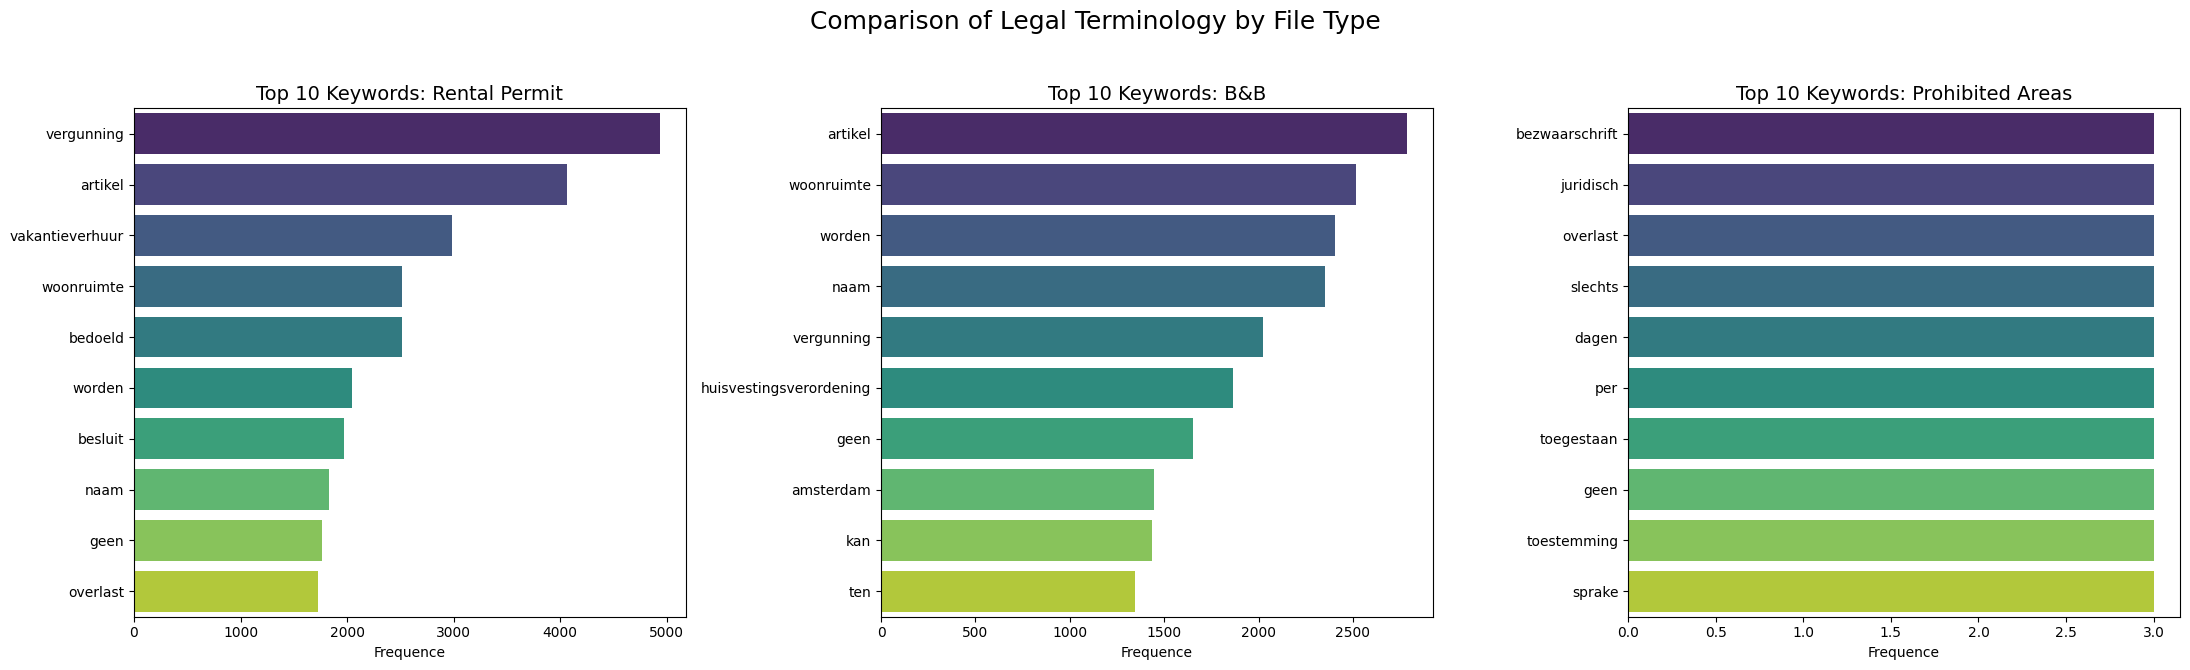

In [38]:

dutch_stop_words = set([
    'de', 'het', 'een', 'en', 'van', 'in', 'is', 'dat', 'op', 'te', 'met', 
    'voor', 'zijn', 'aan', 'niet', 'uit', 'om', 'door', 'ook', 'wordt', 'tot',
    'over', 'bij', 'naar', 'heeft', 'zou', 'moet', 'binnen', 'deze', 'was', 'als',
    'dit', 'die', 'dan'
])

def get_top_keywords(text_series, n=10):
    all_text = " ".join(text_series.astype(str)).lower()
    # Zoek alleen woorden van 3 letters of langer
    words = re.findall(r'\b[a-z]{3,}\b', all_text)
    meaningful_words = [w for w in words if w not in dutch_stop_words]
    return Counter(meaningful_words).most_common(n)

subtypes = ['Rental Permit', 'B&B', 'Prohibited Areas']
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for i, stype in enumerate(subtypes):
    # Filter de data voor dit specifieke subtype
    subset = df[df['Subtype'] == stype]['Legal_Text']
    
    if not subset.empty and len(subset) > 0:
        top_words = get_top_keywords(subset)
        words, counts = zip(*top_words)
        
        # Maak het horizontale staafdiagram
        sns.barplot(ax=axes[i], x=list(counts), y=list(words), palette='viridis')
        axes[i].set_title(f'Top 10 Keywords: {stype}', fontsize=14)
        axes[i].set_xlabel('Frequence')
    else:
        axes[i].text(0.5, 0.5, 'Geen data beschikbaar', ha='center', va='center')
        axes[i].set_title(f'{stype} (Leeg)')

plt.suptitle('Comparison of Legal Terminology by File Type', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The common word analysis demonstrates that the dataset is not noisy text but a structured collection of legal arguments. The distinct linguistic profiles for Rental Permits, B&B, and Prohibited Areas confirm that a one-size-fits-all drafting tool would be insufficient. Instead, a specialized RAG approach that respects these domain-specific vocabularies is required to provide high-quality, professional decision support for municipal practitioners

## 3.3. Complexity Mapping by Dictum and Subtype

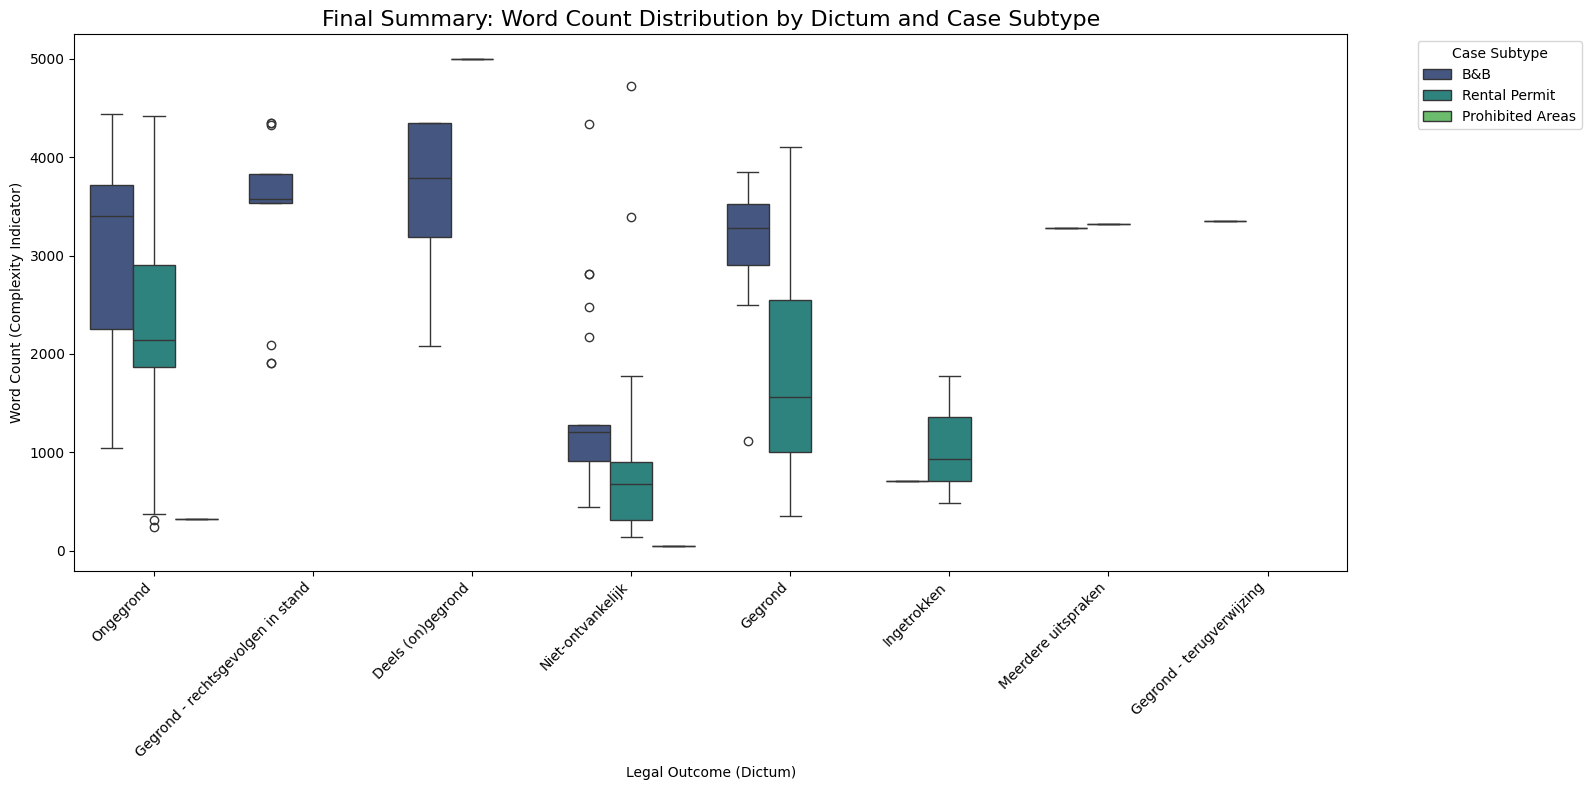

In [46]:
df_hr['word_count'] = df_hr['Legal_Text'].astype(str).str.split().str.len()

plt.figure(figsize=(16, 8))
sns.boxplot(data=df_hr, x='Dictum', y='word_count', hue='Subtype', palette='viridis')

plt.title('Final Summary: Word Count Distribution by Dictum and Case Subtype', fontsize=16)
plt.ylabel('Word Count (Complexity Indicator)')
plt.xlabel('Legal Outcome (Dictum)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Case Subtype', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()

This graph clearly demonstrates that the complexity of a legal draft (measured by word count) is highly dependent on both the case subtype and the legal outcome determined by the practitioner. Across almost all legal outcomes, B&B cases consistently require significantly more words (higher medians) than Rental Permit cases. This indicates that B&B cases involve more extensive legal reasoning and factual justification. The Dictum heavily influences the length of the document. For instance, *Niet-ontvankelijk* (Inadmissible) cases are notably shorter across all subtypes. This aligns with legal practice: if a case is inadmissible (e.g., filed too late), the substantive legal arguments do not need to be addressed, resulting in a concise letter. Categories like *Gegrond* (Sustained), *Deels (on)gegrond*, and *Ongegrond* for B&B cases show large word counts and wide interquartile ranges. These represent the most complex drafting tasks for the municipal lawyer.

## 4. Methodological Advice for RAG Implementation


This analysis proves that a static, "one-size-fits-all" text generation approach will fail. The RAG system must be dynamically tailored to the specific parameters of the case.

*4.1. Dynamic Retrieval Depth (K-value adaptation)*

Since *Niet-ontvankelijk* letters are short and formulaic, the RAG retriever only needs to fetch a small number of chunks (a lower k value) to find the correct procedural template. Conversely, drafting an *Ongegrond* letter for a B&B requires deep substantive reasoning, meaning the retriever should fetch more chunks to capture the full legal context.

*4.2 Metadata Filtering (Addressing Q2)* 

The stark contrast between B&B and Rental Permits confirms that the vector database searches must be strictly filtered by Subtype. When the lawyer inputs that a case is a Rental Permit, the RAG system must only retrieve chunks from historical Rental Permit cases to prevent cross-contamination of legal terminology and policy rules.

*4.3 Context Window Management* 

Because B&B cases regularly exceed 3,000 to 4,000 words, the Large Language Model (LLM) will face heavy context window pressure. The chunking strategy must be highly precise (e.g., stopping at natural paragraph or sentence boundaries) to ensure the prompt is filled only with the highest-value legal arguments, minimizing noise and preventing legal hallucinations.
